# Zero-Shot Learning и Few-Shot Learning: Практическое демо

**Семинар по методам обучения с минимальной разметкой**

Этот ноутбук демонстрирует два ключевых подхода к классификации текстов, когда размеченных данных мало или нет вовсе:

1. **Zero-Shot Classification** — классификация без единого размеченного примера (NLI-подход, Yin et al., 2019)
2. **Few-Shot Classification** — классификация по нескольким примерам на класс (SetFit, Tunstall et al., 2022)

---

### Теоретический фундамент

**Zero-Shot Learning (ZSL)** решает задачу: дано множество классов $\mathcal{Y}^{\text{test}}$, для которых нет ни одного размеченного примера. Модель использует _побочную информацию_ (side information) — атрибуты, текстовые описания, или связь с задачей NLI.

**NLI-подход к ZSL** (Yin et al., 2019): задача классификации сводится к задаче Natural Language Inference:
- **Premise** = входной текст $x$
- **Hypothesis** = `"This text is about {label}"` для каждой метки $y \in \mathcal{Y}$
- Предсказание: $\hat{y} = \arg\max_{y \in \mathcal{Y}} P(\text{entailment} \mid x, h_y)$

**Few-Shot Learning (FSL)** решает задачу N-way K-shot: даны $N$ классов по $K$ примеров каждый (support set $\mathcal{S}$), нужно классифицировать новый пример $x^*$ (query).

**Prototypical Networks** (Snell et al., 2017): прототип класса $k$ — среднее эмбеддингов support-примеров:

$$\mathbf{c}_k = \frac{1}{|\mathcal{S}_k|} \sum_{(x_i, y_i) \in \mathcal{S}_k} f_\theta(x_i)$$

Вероятность класса:

$$p(y = k \mid x^*) = \frac{\exp(-d(f_\theta(x^*), \mathbf{c}_k))}{\sum_{k'} \exp(-d(f_\theta(x^*), \mathbf{c}_{k'}))}$$

где $d$ — евклидово расстояние, $f_\theta$ — нейросетевой энкодер.

**SetFit** (Tunstall et al., 2022): двухэтапный подход:
1. Контрастивное дообучение Sentence Transformer на парах текстов (позитивные/негативные)
2. Обучение классификационной головы (логистическая регрессия) на полученных эмбеддингах

## 0. Установка зависимостей

Запустите эту ячейку в Google Colab (или локально).

In [1]:
!pip install -q transformers datasets setfit torch scikit-learn matplotlib seaborn pandas numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.6/75.6 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 6.8 MB/s eta 0:00:00


In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from time import time

# Фиксируем seed для воспроизводимости
np.random.seed(42)

print("Библиотеки загружены.")

Библиотеки загружены.


---
## 1. Подготовка данных

Используем датасет **AG News** — классификация новостей по 4 категориям:
- World (0)
- Sports (1)
- Business (2)
- Sci/Tech (3)

Мы возьмём подмножество тестовых данных для оценки, а для few-shot — по K примеров на класс из обучающей выборки.

In [3]:
from datasets import load_dataset

# Загрузка AG News
dataset = load_dataset("ag_news")

# Имена классов
label_names = ["World", "Sports", "Business", "Sci/Tech"]
label2id = {name: i for i, name in enumerate(label_names)}

# Подвыборка для тестирования (200 примеров — по 50 на класс)
test_subset = dataset["test"].shuffle(seed=42).select(range(200))

print(f"Тестовая подвыборка: {len(test_subset)} примеров")
print(f"Распределение классов: {pd.Series([label_names[l] for l in test_subset['label']]).value_counts().to_dict()}")
print(f"\nПример текста: {test_subset['text'][0][:200]}...")
print(f"Метка: {label_names[test_subset['label'][0]]}")

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

Тестовая подвыборка: 200 примеров
Распределение классов: {'Business': 54, 'Sports': 52, 'World': 50, 'Sci/Tech': 44}

Пример текста: Indian board plans own telecast of Australia series The Indian cricket board said on Wednesday it was making arrangements on its own to broadcast next month #39;s test series against Australia, which ...
Метка: Sports


---
## 2. Zero-Shot Classification (NLI-подход)

### Как это работает?

Модель `facebook/bart-large-mnli` обучена на задаче Natural Language Inference (MNLI, ~400K пар предложений). Для zero-shot классификации:

1. Входной текст — **premise**
2. Для каждой метки формируется **hypothesis**: `"This text is about {label}"`
3. Модель оценивает $P(\text{entailment})$ для каждой пары
4. Метка с наибольшей вероятностью entailment — предсказание

$$\hat{y} = \arg\max_{y \in \{\text{World, Sports, Business, Sci/Tech}\}} P(\text{entailment} \mid x, \text{"This text is about } y \text{"}$$

**Ключевое преимущество**: не нужно НИ ОДНОГО размеченного примера для целевой задачи.

In [4]:
from transformers import pipeline

# Загрузка zero-shot классификатора
# Модель: BART-large, дообученная на MultiNLI (~400M параметров)
zs_classifier = pipeline(
    "zero-shot-classification",
    model="facebook/bart-large-mnli",
    device=0 if __import__('torch').cuda.is_available() else -1
)

print(f"Модель загружена. GPU: {__import__('torch').cuda.is_available()}")

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Модель загружена. GPU: True


### 2.1 Демонстрация на одном примере

Посмотрим, как модель распределяет вероятности между классами:

In [5]:
# Один пример
example_text = test_subset['text'][0]
true_label = label_names[test_subset['label'][0]]

result = zs_classifier(example_text, candidate_labels=label_names)

print(f"Текст: {example_text[:300]}...\n")
print(f"Истинная метка: {true_label}")
print(f"Предсказание:  {result['labels'][0]}\n")
print("Распределение вероятностей:")
for label, score in zip(result['labels'], result['scores']):
    bar = '█' * int(score * 40)
    print(f"  {label:10s} {score:.4f} {bar}")

Текст: Indian board plans own telecast of Australia series The Indian cricket board said on Wednesday it was making arrangements on its own to broadcast next month #39;s test series against Australia, which is under threat because of a raging TV rights dispute....

Истинная метка: Sports
Предсказание:  Sports

Распределение вероятностей:
  Sports     0.4430 █████████████████
  Sci/Tech   0.2443 █████████
  Business   0.1629 ██████
  World      0.1498 █████


### 2.2 Оценка на тестовой подвыборке

Прогоним модель через все 200 тестовых примеров и оценим accuracy.

In [6]:
from sklearn.metrics import classification_report, confusion_matrix

# Zero-shot предсказания на всём тесте
print("Запуск zero-shot классификации на 200 примерах...")
t0 = time()

zs_predictions = []
zs_scores_all = []

for i, text in enumerate(test_subset['text']):
    res = zs_classifier(text, candidate_labels=label_names)
    pred_label = res['labels'][0]
    zs_predictions.append(label2id[pred_label])
    zs_scores_all.append(dict(zip(res['labels'], res['scores'])))
    if (i + 1) % 50 == 0:
        print(f"  Обработано {i+1}/200")

zs_time = time() - t0
true_labels = test_subset['label']

print(f"\nВремя: {zs_time:.1f} сек ({zs_time/200:.2f} сек/пример)")
print(f"\n{'='*60}")
print("ZERO-SHOT CLASSIFICATION REPORT")
print(f"{'='*60}")
print(classification_report(true_labels, zs_predictions, target_names=label_names, digits=3))

Запуск zero-shot классификации на 200 примерах...


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


  Обработано 50/200
  Обработано 100/200
  Обработано 150/200
  Обработано 200/200

Время: 22.4 сек (0.11 сек/пример)

ZERO-SHOT CLASSIFICATION REPORT
              precision    recall  f1-score   support

       World      0.593     0.700     0.642        50
      Sports      0.942     0.942     0.942        52
    Business      0.667     0.630     0.648        54
    Sci/Tech      0.658     0.568     0.610        44

    accuracy                          0.715       200
   macro avg      0.715     0.710     0.710       200
weighted avg      0.718     0.715     0.715       200



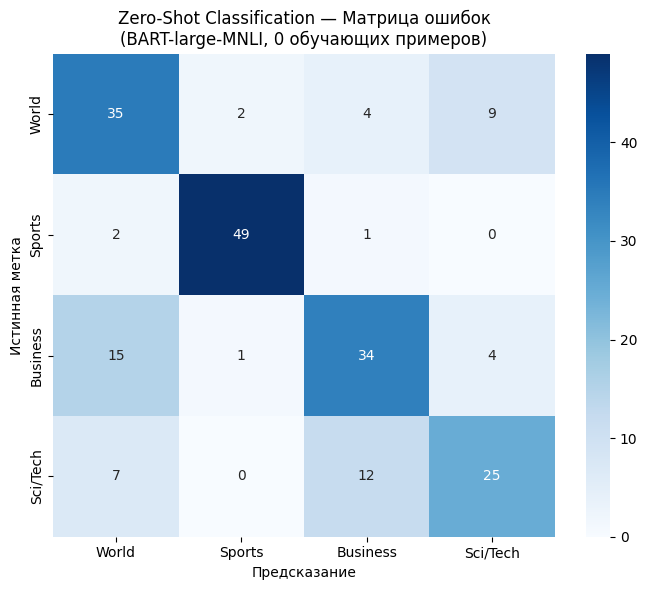

In [7]:
# Матрица ошибок
fig, ax = plt.subplots(1, 1, figsize=(7, 6))
cm = confusion_matrix(true_labels, zs_predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names, ax=ax)
ax.set_xlabel('Предсказание')
ax.set_ylabel('Истинная метка')
ax.set_title('Zero-Shot Classification — Матрица ошибок\n(BART-large-MNLI, 0 обучающих примеров)')
plt.tight_layout()
plt.show()

### 2.3 Влияние формулировки гипотезы

В zero-shot классификации формулировка hypothesis критически важна. Сравним разные шаблоны:

In [8]:
# Сравнение разных шаблонов гипотез
# Используем подмножество из 50 примеров для скорости
small_test = test_subset.select(range(50))

hypothesis_templates = {
    "This text is about {}": None,  # стандартный шаблон (по умолчанию в pipeline)
    "The topic of this article is {}": "The topic of this article is {}",
    "This article covers {} news": "This article covers {} news",
}

template_results = {}

for template_name, template in hypothesis_templates.items():
    preds = []
    for text in small_test['text']:
        if template:
            res = zs_classifier(text, candidate_labels=label_names,
                               hypothesis_template=template)
        else:
            res = zs_classifier(text, candidate_labels=label_names)
        preds.append(label2id[res['labels'][0]])

    acc = np.mean(np.array(preds) == np.array(small_test['label']))
    template_results[template_name] = acc
    print(f"Шаблон: '{template_name}' → Accuracy: {acc:.3f}")

print("\nВывод: формулировка гипотезы существенно влияет на качество zero-shot классификации.")

Шаблон: 'This text is about {}' → Accuracy: 0.720
Шаблон: 'The topic of this article is {}' → Accuracy: 0.800
Шаблон: 'This article covers {} news' → Accuracy: 0.620

Вывод: формулировка гипотезы существенно влияет на качество zero-shot классификации.


---
## 3. Few-Shot Classification (SetFit)

### Как работает SetFit?

**Этап 1: Контрастивное дообучение Sentence Transformer**

Из $K$ примеров на класс генерируются пары:
- **Позитивные** $(x_i, x_j)$: оба из одного класса → метка сходства 1
- **Негативные** $(x_i, x_k)$: из разных классов → метка сходства 0

Функция потерь — Cosine Similarity Loss:

$$\mathcal{L} = \frac{1}{|\mathcal{T}|} \sum_{(x_i, x_j, y)} \left( y - \cos(f_\theta(x_i), f_\theta(x_j)) \right)^2$$

**Этап 2: Обучение классификатора**

На полученных эмбеддингах $f_\theta(x_i)$ обучается логистическая регрессия:

$$p(y = k \mid x) = \text{softmax}(\mathbf{W} f_\theta(x) + \mathbf{b})_k$$

### Архитектура SetFit

```
Входной текст → Sentence Transformer (дообученный контрастивно) → Эмбеддинг (768-dim) → Logistic Regression → Класс
```

**Преимущества** перед prompt-based методами:
- Не требует промптов/вербализаторов
- Работает с моделями на порядок меньше (110M vs 11B параметров)
- Быстрое обучение и инференс

In [15]:
# Патч совместимости setfit с новой версией transformers
import transformers.training_args
if not hasattr(transformers.training_args, 'default_logdir'):
    import datetime
    transformers.training_args.default_logdir = lambda: f"runs/{datetime.datetime.now().strftime('%b%d_%H-%M-%S')}"

!pip install -q setfit --upgrade

In [19]:
from setfit import SetFitModel, SetFitHead, Trainer, sample_dataset
from datasets import Dataset

# Готовим few-shot обучающие данные
# K = 8 примеров на класс (всего 32 примера)
K_SHOT = 8

train_data = dataset["train"].shuffle(seed=42)

# Выбираем по K примеров из каждого класса
few_shot_indices = []
for label_id in range(len(label_names)):
    class_indices = [i for i, l in enumerate(train_data['label']) if l == label_id]
    few_shot_indices.extend(class_indices[:K_SHOT])

train_few_shot = train_data.select(few_shot_indices)

print(f"Few-shot обучающая выборка: {len(train_few_shot)} примеров ({K_SHOT} на класс)")
print(f"Распределение: {pd.Series([label_names[l] for l in train_few_shot['label']]).value_counts().to_dict()}")
print(f"\nПример: '{train_few_shot['text'][0][:150]}...'")
print(f"Метка: {label_names[train_few_shot['label'][0]]}")

Few-shot обучающая выборка: 32 примеров (8 на класс)
Распределение: {'World': 8, 'Sports': 8, 'Business': 8, 'Sci/Tech': 8}

Пример: 'Bangladesh paralysed by strikes Opposition activists have brought many towns and cities in Bangladesh to a halt, the day after 18 people died in explo...'
Метка: World


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [20]:
# Обучение SetFit
from sentence_transformers import SentenceTransformer

print("Загрузка Sentence Transformer модели...")
st_model = SentenceTransformer("sentence-transformers/paraphrase-mpnet-base-v2")

# Создаём SetFitModel через внутренний конструктор (обходим from_pretrained, который ищет config_setfit.json)
model = SetFitModel(model_body=st_model, model_head=SetFitHead(in_features=768, out_features=len(label_names)))

trainer = Trainer(
    model=model,
    train_dataset=train_few_shot,
    eval_dataset=test_subset,
    column_mapping={"text": "text", "label": "label"},
)

print(f"\nНачинаем обучение SetFit на {len(train_few_shot)} примерах...")
t0 = time()
trainer.train()
fs_train_time = time() - t0

print(f"Обучение завершено за {fs_train_time:.1f} сек")
print(f"Параметры модели: ~110M (paraphrase-mpnet-base-v2)")

Загрузка Sentence Transformer модели...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/paraphrase-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Applying column mapping to the training dataset
Applying column mapping to the evaluation dataset
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Map:   0%|          | 0/32 [00:00<?, ? examples/s]

***** Running training *****
  Num unique pairs = 768
  Batch size = 16
  Num epochs = 1


...

Iteration:   0%|          | 0/16 [00:00<?, ?it/s]

Iteration:   0%|          | 0/16 [00:00<?, ?it/s]

Iteration:   0%|          | 0/16 [00:00<?, ?it/s]

Iteration:   0%|          | 0/16 [00:00<?, ?it/s]

Обучение завершено за 71.6 сек
Параметры модели: ~110M (paraphrase-mpnet-base-v2)


In [22]:
# Оценка SetFit
print("Оценка SetFit на тестовой выборке...")
t0 = time()
fs_predictions = model.predict(test_subset['text']).cpu().numpy()
fs_time = time() - t0

print(f"Время инференса: {fs_time:.1f} сек ({fs_time/200:.3f} сек/пример)")
print(f"\n{'='*60}")
print(f"FEW-SHOT CLASSIFICATION REPORT (SetFit, K={K_SHOT})")
print(f"{'='*60}")
print(classification_report(true_labels, fs_predictions, target_names=label_names, digits=3))

Оценка SetFit на тестовой выборке...
Время инференса: 1.1 сек (0.005 сек/пример)

FEW-SHOT CLASSIFICATION REPORT (SetFit, K=8)
              precision    recall  f1-score   support

       World      0.970     0.640     0.771        50
      Sports      0.911     0.981     0.944        52
    Business      0.677     0.778     0.724        54
    Sci/Tech      0.694     0.773     0.731        44

    accuracy                          0.795       200
   macro avg      0.813     0.793     0.793       200
weighted avg      0.815     0.795     0.795       200



/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


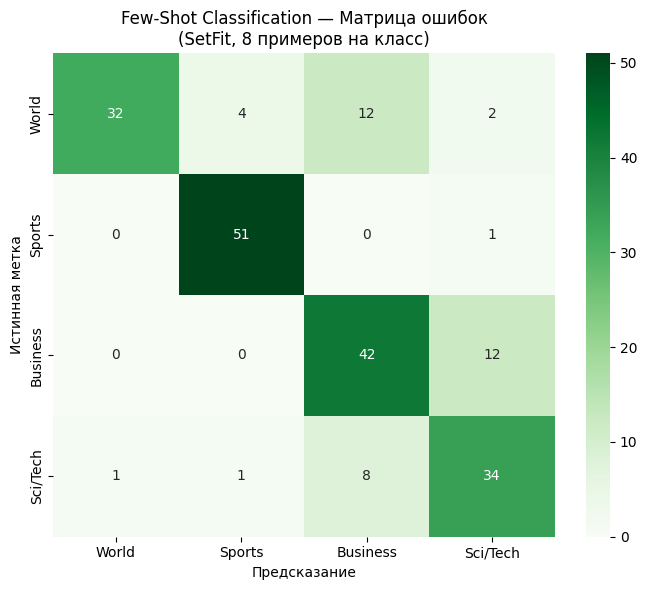

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [23]:
# Матрица ошибок для SetFit
fig, ax = plt.subplots(1, 1, figsize=(7, 6))
cm_fs = confusion_matrix(true_labels, fs_predictions)
sns.heatmap(cm_fs, annot=True, fmt='d', cmap='Greens',
            xticklabels=label_names, yticklabels=label_names, ax=ax)
ax.set_xlabel('Предсказание')
ax.set_ylabel('Истинная метка')
ax.set_title(f'Few-Shot Classification — Матрица ошибок\n(SetFit, {K_SHOT} примеров на класс)')
plt.tight_layout()
plt.show()

---
## 4. Эксперимент: как K (число примеров) влияет на качество?

Один из ключевых вопросов: при каком K few-shot начинает стабильно превосходить zero-shot?

In [24]:
# Эксперимент с разным числом примеров
k_values = [2, 4, 8, 16]
fs_accuracies = {}

for k in k_values:
    print(f"\n--- Обучение SetFit с K={k} ---")

    # Выборка K примеров на класс
    indices = []
    for label_id in range(len(label_names)):
        class_idx = [i for i, l in enumerate(train_data['label']) if l == label_id]
        indices.extend(class_idx[:k])

    train_k = train_data.select(indices)

    # Обучение
    st_k = SentenceTransformer("sentence-transformers/paraphrase-mpnet-base-v2")
    model_k = SetFitModel(model_body=st_k, model_head=SetFitHead(in_features=768, out_features=len(label_names)))
    trainer_k = Trainer(
        model=model_k,
        train_dataset=train_k,
        column_mapping={"text": "text", "label": "label"},
    )
    trainer_k.train()

    # Оценка
    preds = model_k.predict(test_subset['text']).cpu().numpy()
    acc = np.mean(preds == np.array(true_labels))
    fs_accuracies[k] = acc
    print(f"  K={k}: Accuracy = {acc:.3f}")

# Добавляем zero-shot результат
zs_accuracy = np.mean(np.array(zs_predictions) == np.array(true_labels))
print(f"\nZero-shot (BART-MNLI): Accuracy = {zs_accuracy:.3f}")
print(f"Few-shot результаты: {fs_accuracies}")


--- Обучение SetFit с K=2 ---


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/paraphrase-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Applying column mapping to the training dataset
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Map:   0%|          | 0/8 [00:00<?, ? examples/s]

***** Running training *****
  Num unique pairs = 48
  Batch size = 16
  Num epochs = 1
/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py:57: DeprecationWarning: The argument 'device' of Tensor.pin_memory() is deprecated. Please do not pass this argument. (Triggered internally at /pytorch/aten/src/ATen/native/Memory.cpp:46.)
  return data.pin_memory(device)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py:57: DeprecationWarning: The argument 'device' of Tensor.is_pinned() is deprecated. Please do not pass this argument. (Triggered internally at /pytorch/aten/src/ATen/native/Memory.cpp:31.)
  return data.pin_memory(device)


...

Iteration:   0%|          | 0/32 [00:00<?, ?it/s]

Iteration:   0%|          | 0/32 [00:00<?, ?it/s]

Iteration:   0%|          | 0/32 [00:00<?, ?it/s]

Iteration:   0%|          | 0/32 [00:00<?, ?it/s]

  K=16: Accuracy = 0.830

Zero-shot (BART-MNLI): Accuracy = 0.715
Few-shot результаты: {2: np.float64(0.46), 4: np.float64(0.62), 8: np.float64(0.785), 16: np.float64(0.83)}


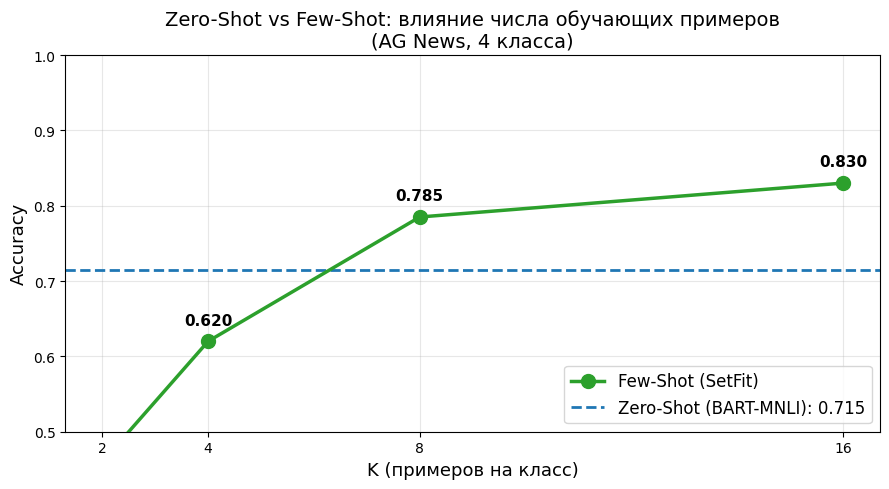

In [25]:
# Визуализация
fig, ax = plt.subplots(1, 1, figsize=(9, 5))

# Few-shot кривая
ks = sorted(fs_accuracies.keys())
accs = [fs_accuracies[k] for k in ks]
ax.plot(ks, accs, 'o-', color='#2ca02c', linewidth=2.5, markersize=10, label='Few-Shot (SetFit)', zorder=3)

# Zero-shot baseline
ax.axhline(y=zs_accuracy, color='#1f77b4', linestyle='--', linewidth=2, label=f'Zero-Shot (BART-MNLI): {zs_accuracy:.3f}')

# Аннотации
for k, acc in zip(ks, accs):
    ax.annotate(f'{acc:.3f}', (k, acc), textcoords='offset points',
                xytext=(0, 12), ha='center', fontsize=11, fontweight='bold')

ax.set_xlabel('K (примеров на класс)', fontsize=13)
ax.set_ylabel('Accuracy', fontsize=13)
ax.set_title('Zero-Shot vs Few-Shot: влияние числа обучающих примеров\n(AG News, 4 класса)', fontsize=14)
ax.set_xticks(ks)
ax.legend(fontsize=12, loc='lower right')
ax.set_ylim(0.5, 1.0)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 5. Сравнительный анализ

Сведём все результаты в таблицу.

In [26]:
# Итоговая таблица сравнения
comparison_data = {
    'Метод': ['Zero-Shot (BART-MNLI)'] + [f'Few-Shot SetFit (K={k})' for k in ks],
    'Обучающих примеров': [0] + [k * len(label_names) for k in ks],
    'Accuracy': [zs_accuracy] + accs,
    'Размер модели': ['~400M'] + ['~110M'] * len(ks),
    'Требует обучения': ['Нет'] + ['Да (< 1 мин)'] * len(ks),
}

df_comparison = pd.DataFrame(comparison_data)
print(df_comparison.to_string(index=False))

                 Метод  Обучающих примеров  Accuracy Размер модели Требует обучения
 Zero-Shot (BART-MNLI)                   0     0.715         ~400M              Нет
 Few-Shot SetFit (K=2)                   8     0.460         ~110M     Да (< 1 мин)
 Few-Shot SetFit (K=4)                  16     0.620         ~110M     Да (< 1 мин)
 Few-Shot SetFit (K=8)                  32     0.785         ~110M     Да (< 1 мин)
Few-Shot SetFit (K=16)                  64     0.830         ~110M     Да (< 1 мин)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


---
## 6. Prototypical Networks — реализация с нуля (бонус)

Для полноты картины реализуем идею Prototypical Networks (Snell et al., 2017) на текстовых эмбеддингах.

Мы используем предобученный Sentence Transformer как $f_\theta$ (без дообучения), вычисляем прототипы как средние эмбеддингов, и классифицируем по ближайшему прототипу.

In [27]:
from sentence_transformers import SentenceTransformer
from scipy.spatial.distance import cdist

# Загрузка энкодера
encoder = SentenceTransformer('sentence-transformers/paraphrase-mpnet-base-v2')

def prototypical_classify(support_texts, support_labels, query_texts, encoder, n_classes):
    """
    Prototypical Networks классификация.

    1. Кодируем support и query тексты в эмбеддинги
    2. Вычисляем прототип каждого класса как среднее эмбеддингов
    3. Классифицируем query по ближайшему прототипу (евклидово расстояние)

    Args:
        support_texts: список текстов support set
        support_labels: метки support set
        query_texts: список текстов для классификации
        encoder: Sentence Transformer модель
        n_classes: число классов

    Returns:
        predictions: массив предсказанных меток
        probabilities: матрица вероятностей (softmax по отрицательным расстояниям)
    """
    # Шаг 1: Получаем эмбеддинги
    support_embeddings = encoder.encode(support_texts, show_progress_bar=False)
    query_embeddings = encoder.encode(query_texts, show_progress_bar=False)

    # Шаг 2: Вычисляем прототипы — c_k = mean(f_θ(x_i)) для каждого класса k
    prototypes = np.zeros((n_classes, support_embeddings.shape[1]))
    for k in range(n_classes):
        mask = np.array(support_labels) == k
        prototypes[k] = support_embeddings[mask].mean(axis=0)

    # Шаг 3: Евклидовы расстояния от каждого query до каждого прототипа
    distances = cdist(query_embeddings, prototypes, metric='euclidean')  # (n_query, n_classes)

    # Шаг 4: Softmax по отрицательным расстояниям → вероятности
    neg_distances = -distances
    exp_neg_dist = np.exp(neg_distances - neg_distances.max(axis=1, keepdims=True))  # для числ. стабильности
    probabilities = exp_neg_dist / exp_neg_dist.sum(axis=1, keepdims=True)

    predictions = probabilities.argmax(axis=1)

    return predictions, probabilities

# Запуск Prototypical Networks с K=8
K = 8
support_indices = []
for label_id in range(len(label_names)):
    class_idx = [i for i, l in enumerate(train_data['label']) if l == label_id]
    support_indices.extend(class_idx[:K])

support_set = train_data.select(support_indices)

print(f"Prototypical Networks: {K}-shot, {len(label_names)}-way")
print(f"Support set: {len(support_set)} примеров")

proto_preds, proto_probs = prototypical_classify(
    support_set['text'], support_set['label'],
    test_subset['text'], encoder, len(label_names)
)

proto_acc = np.mean(proto_preds == np.array(true_labels))
print(f"\nPrototypical Networks Accuracy: {proto_acc:.3f}")
print(f"(без дообучения энкодера — только средние эмбеддинги как прототипы)")
print(f"\n{classification_report(true_labels, proto_preds, target_names=label_names, digits=3)}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/paraphrase-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Prototypical Networks: 8-shot, 4-way
Support set: 32 примеров

Prototypical Networks Accuracy: 0.625
(без дообучения энкодера — только средние эмбеддинги как прототипы)

              precision    recall  f1-score   support

       World      0.738     0.620     0.674        50
      Sports      0.816     0.596     0.689        52
    Business      0.514     0.685     0.587        54
    Sci/Tech      0.542     0.591     0.565        44

    accuracy                          0.625       200
   macro avg      0.652     0.623     0.629       200
weighted avg      0.655     0.625     0.631       200



/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


### 6.1 Визуализация прототипов (t-SNE)

Посмотрим, как выглядят прототипы и тестовые точки в 2D-проекции.

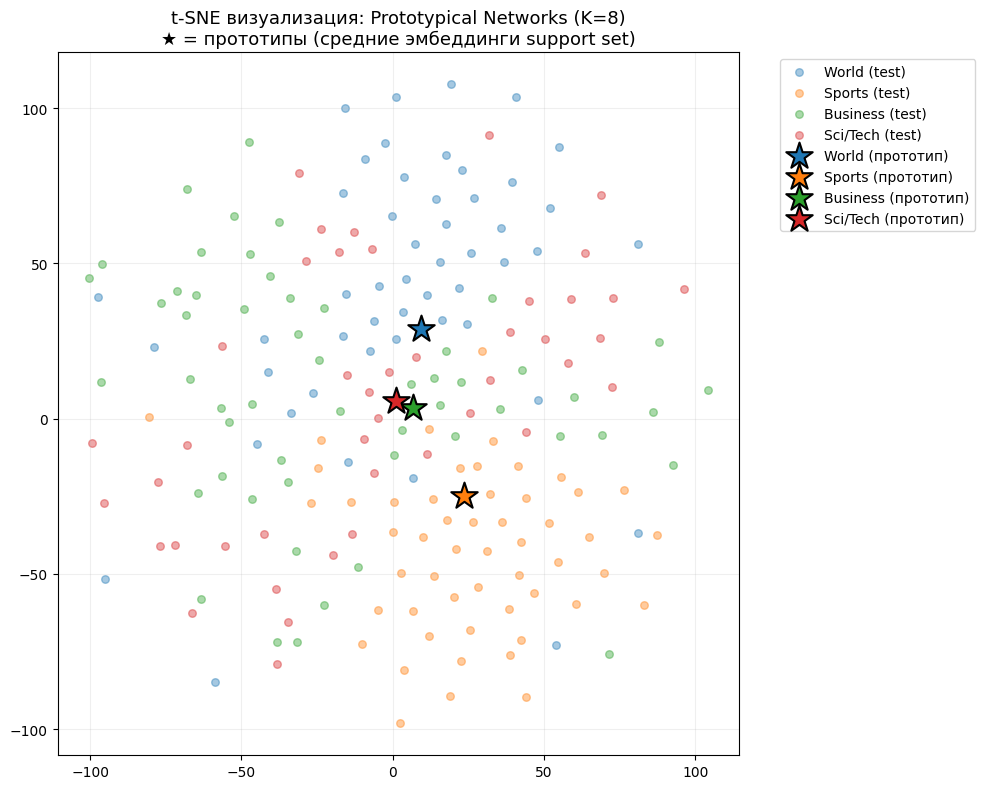

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [28]:
from sklearn.manifold import TSNE

# Получаем эмбеддинги
support_embs = encoder.encode(support_set['text'], show_progress_bar=False)
test_embs = encoder.encode(test_subset['text'], show_progress_bar=False)

# Прототипы
prototypes = np.zeros((len(label_names), support_embs.shape[1]))
for k in range(len(label_names)):
    mask = np.array(support_set['label']) == k
    prototypes[k] = support_embs[mask].mean(axis=0)

# Объединяем для t-SNE
all_embs = np.vstack([test_embs, prototypes])
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
all_2d = tsne.fit_transform(all_embs)

test_2d = all_2d[:len(test_embs)]
proto_2d = all_2d[len(test_embs):]

# Визуализация
fig, ax = plt.subplots(1, 1, figsize=(10, 8))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for k, (name, color) in enumerate(zip(label_names, colors)):
    mask = np.array(true_labels) == k
    ax.scatter(test_2d[mask, 0], test_2d[mask, 1],
              c=color, alpha=0.4, s=30, label=f'{name} (test)')

# Прототипы — большие звёзды
for k, (name, color) in enumerate(zip(label_names, colors)):
    ax.scatter(proto_2d[k, 0], proto_2d[k, 1],
              c=color, marker='*', s=400, edgecolors='black', linewidths=1.5,
              label=f'{name} (прототип)', zorder=5)

ax.set_title(f't-SNE визуализация: Prototypical Networks (K={K})\n'
             f'★ = прототипы (средние эмбеддинги support set)', fontsize=13)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

---
## 7. Итоговое сравнение всех методов


ФИНАЛЬНОЕ СРАВНЕНИЕ МЕТОДОВ
                      Метод  Accuracy  Обучающих примеров             Дообучение
      Zero-Shot (BART-MNLI)     0.715                   0                    Нет
Prototypical Networks (K=8)     0.625                  32 Нет (только прототипы)
               SetFit (K=8)     0.785                  32     Да (контрастивное)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


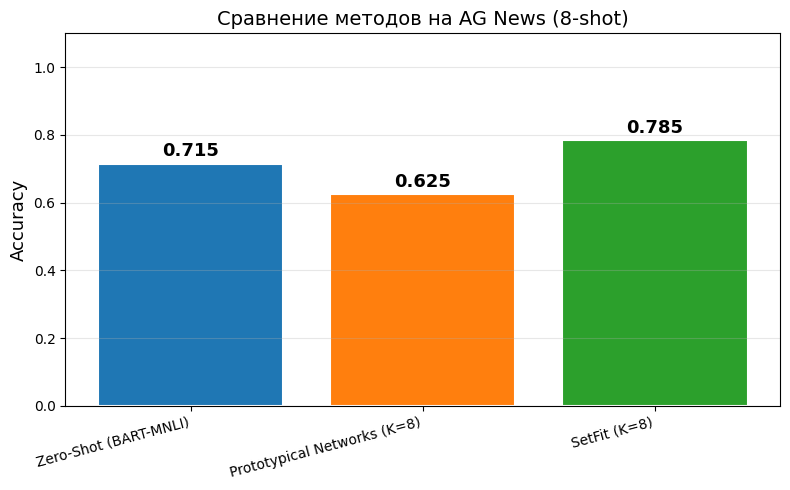

In [29]:
# Финальное сравнение
final_comparison = {
    'Метод': [
        'Zero-Shot (BART-MNLI)',
        f'Prototypical Networks (K={K})',
        f'SetFit (K={K})',
    ],
    'Accuracy': [
        zs_accuracy,
        proto_acc,
        fs_accuracies.get(K, 0),
    ],
    'Обучающих примеров': [
        0,
        K * len(label_names),
        K * len(label_names),
    ],
    'Дообучение': [
        'Нет',
        'Нет (только прототипы)',
        'Да (контрастивное)',
    ],
}

df_final = pd.DataFrame(final_comparison)
print("\n" + "="*70)
print("ФИНАЛЬНОЕ СРАВНЕНИЕ МЕТОДОВ")
print("="*70)
print(df_final.to_string(index=False))

# Гистограмма
fig, ax = plt.subplots(figsize=(8, 5))
bar_colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
bars = ax.bar(df_final['Метод'], df_final['Accuracy'], color=bar_colors, edgecolor='white', linewidth=1.5)

for bar, acc in zip(bars, df_final['Accuracy']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{acc:.3f}', ha='center', va='bottom', fontsize=13, fontweight='bold')

ax.set_ylabel('Accuracy', fontsize=13)
ax.set_title(f'Сравнение методов на AG News ({K}-shot)', fontsize=14)
ax.set_ylim(0, 1.1)
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

---
## 8. Выводы

### Ключевые результаты:

1. **Zero-Shot (NLI-подход)** — работает без единого примера. Качество сильно зависит от формулировки гипотезы и предобучения модели на NLI. Хорошо подходит для быстрого прототипирования.

2. **Prototypical Networks** — простейший few-shot метод: среднее эмбеддингов = прототип класса. Без дообучения энкодера результат зависит от качества предобученных представлений.

3. **SetFit** — контрастивное дообучение Sentence Transformer существенно улучшает качество. С 8 примерами на класс может конкурировать с моделями в 30 раз больше.

### Когда что использовать:

| Ситуация | Рекомендация |
|----------|-------------|
| Нет размеченных данных вовсе | Zero-Shot (NLI) |
| 2–4 примера на класс | Prototypical Networks / SetFit |
| 8–16 примеров на класс | SetFit (явный лидер) |
| Новые классы появляются динамически | Zero-Shot или Prototypical Networks |

### Ссылки на статьи:

- Lampert, C.H., Nickisch, H., Harmeling, S. (2009). *Learning to Detect Unseen Object Classes by Between-Class Attribute Transfer.* CVPR 2009.
- Yin, W., Hay, J., Roth, D. (2019). *Benchmarking Zero-shot Text Classification: Datasets, Evaluation and Entailment Approach.* EMNLP 2019.
- Snell, J., Swersky, K., Zemel, R. (2017). *Prototypical Networks for Few-shot Learning.* NeurIPS 2017.
- Tunstall, L. et al. (2022). *Efficient Few-Shot Learning Without Prompts.* arXiv:2209.11055.
- Vinyals, O. et al. (2016). *Matching Networks for One Shot Learning.* NeurIPS 2016.
- Finn, C., Abbeel, P., Levine, S. (2017). *Model-Agnostic Meta-Learning for Fast Adaptation of Deep Networks.* ICML 2017.